In [32]:
# support vector machine: A Support Vector Machine is fundamentally a constrained optimization problem
# tries to find the best boundary known as hyperplane that separates different classes in the data.
# for multiple classes: Trains a separate binary classifier for every possible pair of classes and uses a voting system to pick the final class.

In [33]:
from sklearn.datasets import load_breast_cancer
import pandas as pd

# load_breast_cancer is bunch object : dictionary 
cancer=load_breast_cancer()
df=pd.DataFrame(cancer.data, columns=cancer.feature_names)
df.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [34]:
df=df[['mean radius','mean texture']]
# X=cancer.data[:,:2]
# same as choose the all rows and first 2 column [0,2) of the bunch object 
df['target']=cancer.target
df.head(10)


,mean radius,mean texture,target
0,17.99,10.38,0
1,20.57,17.77,0
2,19.69,21.25,0
3,11.42,20.38,0
4,20.29,14.34,0
5,12.45,15.70,0
6,18.25,19.98,0
7,13.71,20.83,0
8,13.00,21.82,0
9,12.46,24.04,0


In [35]:
df.tail(10)

,mean radius,mean texture,target
559,11.51,23.93,1
560,14.05,27.15,1
561,11.20,29.37,1
562,15.22,30.62,0
563,20.92,25.09,0
564,21.56,22.39,0
565,20.13,28.25,0
566,16.60,28.08,0
567,20.60,29.33,0
568,7.76,24.54,1


In [36]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(df[['mean radius','mean texture']],df['target'],test_size=0.2,random_state=42)
print("Train size", len(x_train))
print("Test size", len(x_test))

Train size 455
Test size 114


In [ ]:
from sklearn.svm import SVC
svm=SVC(kernel="linear",C=1)
# Positive definite symmetric kernels are used for similarity calculations and are suitable for machine learning algorithms such as SVM. 
#  In contrast, negative definite symmetric kernels are used for distance computations and are applied in clustering techniques.
# model configuration
# linear kernel-> boundary is a straight line: flat hyperplane to separate classes
# RBF kernel-> wavy curve bend around cluster -->for non-linear(higher dimension) :curve/circle hyperplane to separate classes
# polynomial kernel-> smooth curve 
# C: penatly for making classification mistake
svm.fit(x_train,y_train)
# fitted attributes:results of the model learning from your data.
# classes_ ([0, 1]): The unique categories the model discovered in your target variable (e.g., malignant vs. benign).
# n_features_in_ (2): How many input columns (features) your model was trained on.
# coef_ & intercept_: These are the actual mathematical numbers for your straight boundary line (the slope and y-intercept in y = mx + b).
# support_vectors_: the most important concept in an SVM. Support vectors are the specific data points from your dataset that sit closest to the dividing line. The SVM relies only on these specific points to build its boundary; all other data points are ignored.
# n_support_ ([64, 65]): Tells you how many support vectors belong to each class (64 from class 0, and 65 from class 1).

,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'linear'
,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide <shrinking_svm>`.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide <scores_probabilities>`...deprecated:: 1.9 The `probability` parameter is deprecated and will be removed in 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`.",'deprecated'
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False


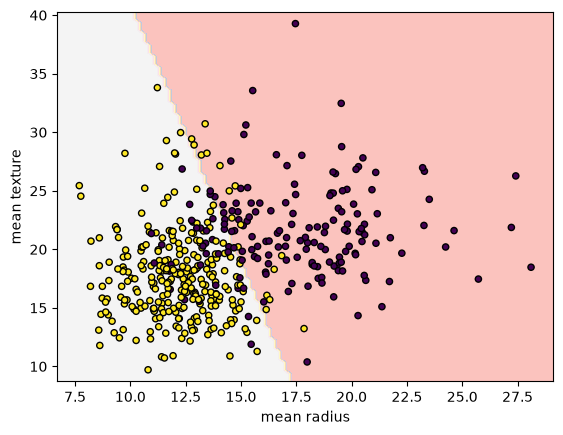

In [ ]:
from sklearn.inspection import DecisionBoundaryDisplay
DecisionBoundaryDisplay.from_estimator(
    svm,
    # the fitted model 
    x_train,
    # training feature, used to determine the plot's range (min/max of each feature)
    response_method="predict",
    # method to call: predict/predict_proba/decision_function
    # predict-> hard class label(0/1)  predict_proba-> probabilities  decision_function->raw scores 
    alpha=0.8,
    # transparency:0->invisible 1->opaque 
    cmap="Pastel1",
    # colormap:color used to shade the region 
    xlabel=cancer.feature_names[0],
    ylabel=cancer.feature_names[1],
)

# to overlay the data points 
import matplotlib.pyplot as plt
plt.scatter(x_train['mean radius'],x_train['mean texture'],
            c=y_train,
            # color of each point:Color = the sample's true label (0 = malignant, 1 = benign)
            s=20,edgecolors="k")
plt.show()